# Spatial correlation of passenger-allele mutations

First-cut analysis for
[matsengrp/gcreplay#179](https://github.com/matsengrp/gcreplay/issues/179):
compute and plot the spatial correlation function
$f(r) = n(r)/n_m(r)$ on gcreplay passenger (chigy stop allele) reads,
where $n(r)$ is the observed number of mutation pairs at genomic
distance $r$ and $n_m(r)$ is the expected number under the
independent-sites null $n_m(r) = N_\text{reads} \sum_{|i-j|=r,\,i<j} p_i p_j$.

Because the passenger allele is out-of-frame and carries a stop,
every read is selection-free, so any short-range enrichment of
$f(r)$ above 1 cannot be attributed to epistasis and is a direct
probe of the SHM machinery. This follows
[Spisak et al. 2020](https://doi.org/10.1093/nar/gkaa825), which
found up to 5× enrichment at short $r$ in productive and
non-productive repertoire data, and complements the "multihit
correction" in [Matsen et al. 2025 (DASM)](https://doi.org/10.1101/2025.10.21.683652)
which lumps this phenomenon into three scalar rate multipliers
per codon.

The final target of this notebook is an HTML render (not committed);
the notebook itself is also not committed.

## Setup

In [1]:
import sys
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
import passenger as P
from passenger import (
    CHIGY_HC,
    CHIGY_LC,
    blast_df_of_blast_files,
    mutation_frequency_by_position_of,
)

RNG = np.random.default_rng(20250409)
sns.set_theme(context="notebook", style="whitegrid")

## Shared filter matching the per-dataset notebooks

Every `passenger-{igh,8a,9a,11a}.ipynb` notebook applies the same
`chigy_believable` filter:

- `mutation_count < 10`
- `n_count < 10`
- `bookended_by_gaps == True`
- `gap_segment_count ∈ {2, 3}`

The `mutation_count < 10` cap is a property of the upstream pipeline;
the issue's proposed "≤15 HC / ≤10 LC" all-load stratum is
unreachable as a result, so we use `≤ 9` (all-load) and `≤ 5`
(low-load, closer to single-SHM-event regime) strata.

In [2]:
MAX_MUTATION_COUNT = 10  # matches every per-dataset notebook
MAX_N_COUNT = 10
ALLOWABLE_GAP_SEGMENT_COUNTS = [2, 3]
LOW_LOAD_CAP = 5  # mutation_count <= 5


def apply_believable_filter(processed_stop_df: pd.DataFrame) -> pd.DataFrame:
    df = processed_stop_df[
        (processed_stop_df["mutation_count"] < MAX_MUTATION_COUNT)
        & (processed_stop_df["n_count"] < MAX_N_COUNT)
        & (processed_stop_df["bookended_by_gaps"] == True)
    ].copy()
    df = df[df["gap_segment_count"].isin(ALLOWABLE_GAP_SEGMENT_COUNTS)]
    return df

## Load and align reads

HC: every `passenger-blast/outname_[5-7]*.tsv`, aligned to
`CHIGY_HC`, `query_length = 20` (matches `passenger-igh.ipynb`).

LC: the three `8A`, `9A`, `11A` files, aligned to `CHIGY_LC` at the
query lengths used in each per-dataset notebook (8A: 32, 9A: 30,
11A: 32).

This re-runs `Passenger.processed_stop_df_of_blast_df` on the BLAST
outputs already on disk, because per-read `mutation_positions` are
not serialized by the existing aggregate notebooks.

In [3]:
HC_BLAST_PATHS = sorted(glob("passenger-blast/outname_[5-7]*.tsv"))
HC_BLAST_PATHS

['passenger-blast/outname_5_IgG_S4_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_5_IgM_S1_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_5_S1_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_6A_S2_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_6_IgG_S5_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_6_IgM_S2_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_7B_S3_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_7_IgG_S6_R1_001_atleast-2.blast.tsv',
 'passenger-blast/outname_7_IgM_S3_R1_001_atleast-2.blast.tsv']

In [4]:
LC_SPECS = [
    {"path": "passenger-blast/outname_AV_IgYKSTOP_8A_S2_R1_001_atleast-2.blast.tsv", "query_length": 32},
    {"path": "passenger-blast/outname_AV_IgYKSTOP_9A_S3_R1_001_atleast-2.blast.tsv", "query_length": 30},
    {"path": "passenger-blast/outname_AV_IgYKSTOP_11A_S1_R1_001_atleast-2.blast.tsv", "query_length": 32},
]


def build_processed_df(chigy, blast_paths, query_length):
    blast_df = blast_df_of_blast_files(blast_paths, query_length)
    return chigy.processed_stop_df_of_blast_df(blast_df)

The pairwise alignment step is expensive (tens of thousands of reads,
serial Python). We cache the raw `processed_stop_df` outputs to
parquet in `_ignore/` (already gitignored) so repeated runs of this
notebook are cheap. Delete `_ignore/mnm_cache_{hc,lc}.parquet` to
force a rebuild.

In [5]:
CACHE_DIR = Path("_ignore")
CACHE_DIR.mkdir(exist_ok=True)
HC_CACHE = CACHE_DIR / "mnm_cache_hc.pkl"
LC_CACHE = CACHE_DIR / "mnm_cache_lc.pkl"

In [6]:
if HC_CACHE.exists():
    print(f"Loading HC from cache {HC_CACHE} ...")
    hc_raw = pd.read_pickle(HC_CACHE)
else:
    print("Building HC processed_stop_df (slow: alignment step) ...")
    hc_raw = build_processed_df(CHIGY_HC, HC_BLAST_PATHS, query_length=20)
    hc_raw.to_pickle(HC_CACHE)
hc_bel = apply_believable_filter(hc_raw)
print(f"HC: {len(hc_raw)} raw, {len(hc_bel)} believable")

Loading HC from cache _ignore/mnm_cache_hc.pkl ...
HC: 35498 raw, 26896 believable


In [7]:
if LC_CACHE.exists():
    print(f"Loading LC from cache {LC_CACHE} ...")
    lc_raw = pd.read_pickle(LC_CACHE)
else:
    print("Building LC processed_stop_df (slow: alignment step) ...")
    lc_frames = []
    for spec in LC_SPECS:
        df = build_processed_df(CHIGY_LC, [spec["path"]], spec["query_length"])
        lc_frames.append(df)
    lc_raw = pd.concat(lc_frames, ignore_index=True)
    lc_raw.to_pickle(LC_CACHE)
lc_bel = apply_believable_filter(lc_raw)
print(f"LC: {len(lc_raw)} raw, {len(lc_bel)} believable")

Loading LC from cache _ignore/mnm_cache_lc.pkl ...


LC: 155341 raw, 128137 believable


### Assign isotype labels

Runs 5/6/7 have IgM- and IgG-labeled datasets (`_IgM_` / `_IgG_` in
the dataset name). Runs 8A/9A/11A are IgM-only (they come from the
`outname_AV_IgYKSTOP_*` series; the "IgY-KSTOP" in the name is the
passenger construct, not the sequenced isotype), so they are
pooled into a single "IgM (8A/9A/11A)" panel. Files named
`outname_[5-7]*_S*_R1_*` without an `_IgM_`/`_IgG_` token are
dropped from the isotype stratification because their isotype is
not explicit from the filename.

In [8]:
def label_isotype(dataset: str) -> str:
    if "_IgM_" in dataset:
        return "IgM"
    if "_IgG_" in dataset:
        return "IgG"
    if "AV_IgYKSTOP" in dataset:
        return "IgM (8A/9A/11A)"
    return "other"


hc_bel["isotype"] = hc_bel["dataset"].map(label_isotype)
lc_bel["isotype"] = lc_bel["dataset"].map(label_isotype)
print("HC isotype counts:")
print(hc_bel["isotype"].value_counts())
print()
print("LC isotype counts:")
print(lc_bel["isotype"].value_counts())

HC isotype counts:
isotype
IgM      15504
IgG       7354
other     4038
Name: count, dtype: int64

LC isotype counts:
isotype
IgM (8A/9A/11A)    128137
Name: count, dtype: int64


## Spatial correlation core

Given a set of reads (each with a sorted list of mutation positions
on a fixed template of length $L$) and a per-site mutation
probability vector $p \in [0,1]^L$:

- $n(r)$ — observed pair count at distance $r$: for each read, for
  each pair $(i < j)$ of mutation positions, increment the bin
  $r = j - i$.
- $n_m(r)$ — analytic independent-sites expectation:
  $n_m(r) = N_\text{reads} \sum_{i<j,\,j-i=r} p_i p_j$.
- $f(r) = n(r) / n_m(r)$.

Bootstrap CI on $f(r)$: resample reads with replacement `B` times,
recompute $n(r)$, divide by the (fixed) $n_m(r)$, report
2.5 / 97.5 percentiles.

Permutation null band on $f(r)$: for each read with $k$ mutations,
draw $k$ positions *without replacement* from
$\{0,\dots,L-1\}$ with probabilities $p_i / \sum_j p_j$, repeat `B`
times, compute $f(r)$. Under $H_0$ (per-site independence within a
read), this band should cover 1.

In [9]:
def observed_pair_histogram(mutation_positions_series, L: int) -> np.ndarray:
    """Return n(r) for r in [0, L-1]; only r >= 1 is meaningful.

    Vectorized: for each read with k mutations, compute all k*(k-1)/2
    pair distances with ``np.subtract.outer``-style broadcasting and
    accumulate into ``hist`` via ``np.bincount``.
    """
    all_diffs = []
    for positions in mutation_positions_series:
        k = len(positions)
        if k < 2:
            continue
        arr = np.sort(np.asarray(positions, dtype=np.int64))
        # j > i so arr[j] - arr[i] > 0
        diffs = arr[None, :] - arr[:, None]
        iu = np.triu_indices(k, k=1)
        all_diffs.append(diffs[iu])
    if not all_diffs:
        return np.zeros(L, dtype=np.int64)
    concat = np.concatenate(all_diffs).astype(np.int64)
    concat = concat[(concat > 0) & (concat < L)]
    hist = np.bincount(concat, minlength=L).astype(np.int64)
    if len(hist) > L:
        hist = hist[:L]
    return hist


def analytic_null_histogram(p: np.ndarray, n_reads: int) -> np.ndarray:
    """n_m(r) = n_reads * sum_{i<j, j-i=r} p_i p_j via FFT-style shifts.

    Implementation: for each shift r in [1, L-1], compute
    sum_i p_i * p_{i+r} and multiply by n_reads.
    """
    L = len(p)
    out = np.zeros(L, dtype=np.float64)
    for r in range(1, L):
        out[r] = float(np.dot(p[:-r], p[r:]))
    return n_reads * out


def empirical_p(bel_df: pd.DataFrame, L: int) -> np.ndarray:
    """Per-site mutation probability (mean over reads).

    Uses ``mutation_frequency_by_position_of`` to get counts/reads,
    then extends with zeros to length L if needed.
    """
    freq = mutation_frequency_by_position_of(bel_df)
    p = np.zeros(L, dtype=np.float64)
    p[: len(freq)] = freq
    return p


def precompute_read_pair_diffs(
    positions_list: list[np.ndarray], L: int
) -> list[np.ndarray]:
    """For each read, return a 1-D int64 array of its pair distances
    (already clipped to ``1 <= d < L``). Reads with <2 mutations give
    an empty array. This lets the bootstrap skip alignment-level work.
    """
    per_read = []
    for positions in positions_list:
        k = len(positions)
        if k < 2:
            per_read.append(np.empty(0, dtype=np.int64))
            continue
        arr = np.sort(np.asarray(positions, dtype=np.int64))
        diffs = arr[None, :] - arr[:, None]
        iu = np.triu_indices(k, k=1)
        d = diffs[iu]
        d = d[(d > 0) & (d < L)]
        per_read.append(d.astype(np.int64))
    return per_read


def hist_from_read_diffs(
    per_read_diffs: list[np.ndarray], indices: np.ndarray, L: int
) -> np.ndarray:
    concat_parts = [per_read_diffs[i] for i in indices]
    if not concat_parts:
        return np.zeros(L, dtype=np.int64)
    concat = np.concatenate(concat_parts) if concat_parts else np.empty(0, dtype=np.int64)
    if concat.size == 0:
        return np.zeros(L, dtype=np.int64)
    return np.bincount(concat, minlength=L)[:L].astype(np.int64)


def bootstrap_f_ci(
    per_read_diffs: list[np.ndarray],
    n_m: np.ndarray,
    L: int,
    n_boot: int = 400,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (f_mean, f_lo, f_hi) from read-level bootstrap using
    precomputed per-read pair-distance arrays."""
    rng = rng or np.random.default_rng()
    n = len(per_read_diffs)
    f_samples = np.zeros((n_boot, L), dtype=np.float64)
    idx_array = np.arange(n)
    for b in range(n_boot):
        idx = rng.choice(idx_array, size=n, replace=True)
        obs = hist_from_read_diffs(per_read_diffs, idx, L)
        with np.errstate(divide="ignore", invalid="ignore"):
            f_samples[b] = np.where(n_m > 0, obs / n_m, np.nan)
    f_mean = np.nanmean(f_samples, axis=0)
    f_lo = np.nanpercentile(f_samples, 2.5, axis=0)
    f_hi = np.nanpercentile(f_samples, 97.5, axis=0)
    return f_mean, f_lo, f_hi


def _gumbel_topk(
    m: int, k: int, log_probs: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    """Draw ``m`` samples of ``k`` distinct positions from a
    categorical distribution with log-probabilities ``log_probs``
    (length L). Returns an (m, k) array of indices. Uses the Gumbel
    top-k trick: adding Gumbel(0,1) noise to log-probabilities and
    taking the top-k argmax is equivalent to sampling without
    replacement from the softmax distribution.
    """
    L = len(log_probs)
    # Gumbel(0,1): -log(-log(U)) with U ~ Uniform(0,1)
    u = rng.random((m, L))
    # clip to avoid log(0)
    np.clip(u, 1e-12, 1 - 1e-12, out=u)
    gumbel = -np.log(-np.log(u))
    scores = gumbel + log_probs[None, :]
    # top-k indices per row via argpartition
    # argpartition places the k largest in the last k slots (unordered)
    idx = np.argpartition(scores, -k, axis=1)[:, -k:]
    idx.sort(axis=1)
    return idx


def permutation_null_band(
    mutation_counts: np.ndarray,
    p: np.ndarray,
    n_m: np.ndarray,
    L: int,
    n_perm: int = 200,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Null band on f(r) under per-site independence within reads.

    For each read with k mutations, draw k positions without
    replacement from range(L) with probabilities proportional to p,
    build the pair histogram, divide by n_m. Repeat n_perm times.

    Vectorized: groups reads by ``k``, then for each perm and each
    ``k`` draws all M_k reads at once with the Gumbel top-k trick.
    Empty-category reads (k<2) are skipped.
    """
    rng = rng or np.random.default_rng()
    probs = p / p.sum()
    probs = np.clip(probs, 1e-20, None)
    log_probs = np.log(probs)
    counts = mutation_counts.astype(np.int64)
    counts = counts[counts >= 2]
    unique_k, counts_per_k = np.unique(counts, return_counts=True)
    f_samples = np.zeros((n_perm, L), dtype=np.float64)
    for b in range(n_perm):
        all_diffs = []
        for k, m in zip(unique_k, counts_per_k):
            draws = _gumbel_topk(int(m), int(k), log_probs, rng)  # (m, k)
            # pairwise diffs for each row: (m, k, k) - (m, k, k)
            # we only need upper triangle
            diffs = draws[:, None, :] - draws[:, :, None]  # (m, k, k)
            iu = np.triu_indices(int(k), k=1)
            # extract upper-triangle pairs: (m, num_pairs)
            pair_d = diffs[:, iu[0], iu[1]].ravel()
            pair_d = pair_d[(pair_d > 0) & (pair_d < L)]
            all_diffs.append(pair_d.astype(np.int64))
        if all_diffs:
            concat = np.concatenate(all_diffs)
            hist = np.bincount(concat, minlength=L)[:L].astype(np.int64)
        else:
            hist = np.zeros(L, dtype=np.int64)
        with np.errstate(divide="ignore", invalid="ignore"):
            f_samples[b] = np.where(n_m > 0, hist / n_m, np.nan)
    med = np.nanmedian(f_samples, axis=0)
    lo = np.nanpercentile(f_samples, 2.5, axis=0)
    hi = np.nanpercentile(f_samples, 97.5, axis=0)
    return med, lo, hi

### Correctness validations (implementation tests)

These must pass before we trust the biological plots. Each test is
described in the issue's "Correctness validations" section.

**Test 3 — two-mutation degenerate case.** For reads with exactly 2
mutations, the total pair count equals the read count.

In [10]:
def test_two_mutation_case():
    mps = [np.array([3, 17]), np.array([1, 2]), np.array([5, 29])]
    hist = observed_pair_histogram(mps, L=100)
    assert hist.sum() == 3, (hist.sum(), 3)
    # expected pair distances: 14, 1, 24
    assert hist[14] == 1
    assert hist[1] == 1
    assert hist[24] == 1
    print("test_two_mutation_case: OK")


test_two_mutation_case()

test_two_mutation_case: OK


**Test 1 — known-answer synthetic null.** The analytic null formula
$n_m(r) = N \sum p_i p_j$ assumes *per-site independent Bernoulli*
draws (each site `i` mutates independently with probability `p_i`).
To validate the analytic formula end-to-end, we generate synthetic
reads under exactly that model and check that $f(r) \approx 1$.

Note that this is **not** the same as drawing a fixed `k` positions
without replacement — the two differ for concentrated `p` (e.g. HC
hotspots). The per-site Bernoulli generator gives variable `k` per
read but exactly matches the analytic null's implicit generative
model. The "fixed-k" perturbation on real data is handled by the
permutation null band in the main analysis below, which uses the
per-read `k` distribution as a constraint.

In [11]:
def generate_bernoulli_reads(
    n_reads: int, p: np.ndarray, rng: np.random.Generator
) -> list[np.ndarray]:
    """Draw ``n_reads`` synthetic reads under per-site Bernoulli(p_i)."""
    L = len(p)
    # draw a big uniform matrix and compare to p
    uniforms = rng.random((n_reads, L))
    mask = uniforms < p[None, :]
    out = []
    for row in mask:
        out.append(np.where(row)[0].astype(np.int64))
    return out


def generate_synthetic_reads_fixed_k(
    mutation_counts: np.ndarray,
    p: np.ndarray,
    rng: np.random.Generator,
) -> list[np.ndarray]:
    """Draw ``len(mutation_counts)`` reads: each has `k` positions
    sampled without replacement with probabilities proportional to
    `p`. Used by the permutation null band, NOT by the analytic-null
    correctness test."""
    L = len(p)
    probs = p / p.sum()
    positions = np.arange(L)
    out = []
    for k in mutation_counts:
        k = int(k)
        if k < 2:
            out.append(np.array([], dtype=np.int64))
            continue
        draw = rng.choice(positions, size=k, replace=False, p=probs)
        draw.sort()
        out.append(draw)
    return out


def run_known_answer_null(
    bel_df: pd.DataFrame, L: int, label: str, n_synth: int = 50000
) -> None:
    p = empirical_p(bel_df, L)
    synth_positions = generate_bernoulli_reads(n_synth, p, RNG)
    obs = observed_pair_histogram(synth_positions, L)
    n_m = analytic_null_histogram(p, n_reads=n_synth)
    with np.errstate(divide="ignore", invalid="ignore"):
        f = np.where(n_m > 0, obs / n_m, np.nan)
    r_vals = np.arange(1, min(31, L))
    f_slice = f[r_vals]
    mean_f = float(np.nanmean(f_slice))
    max_dev = float(np.nanmax(np.abs(f_slice - 1)))
    print(f"{label} synthetic null: mean f(r) over r∈[1,30] = {mean_f:.3f}")
    print(f"  min {np.nanmin(f_slice):.3f}, max {np.nanmax(f_slice):.3f}")
    print(f"  max |f(r) - 1| = {max_dev:.3f}")
    # tolerance: with 50k synthetic reads, Poisson noise on n(r) is
    # ~O(1/sqrt(n_m(r))) which is small; a passing test should be
    # within ~10% of 1 at short r.
    assert mean_f < 1.1 and mean_f > 0.9, (
        f"{label} synthetic null mean f(r)={mean_f:.3f} far from 1; "
        "the analytic null formula or the histogram is buggy"
    )


run_known_answer_null(hc_bel, L=len(CHIGY_HC.chigy_stop_trimmed), label="HC")
run_known_answer_null(lc_bel, L=len(CHIGY_LC.chigy_stop_trimmed), label="LC")

HC synthetic null: mean f(r) over r∈[1,30] = 0.995
  min 0.943, max 1.049
  max |f(r) - 1| = 0.057


LC synthetic null: mean f(r) over r∈[1,30] = 0.994
  min 0.937, max 1.076
  max |f(r) - 1| = 0.076


**Test 2 — within-read position shuffle invariance.** For each real
read, replace its positions by $k$ positions drawn without
replacement from the empirical marginal. This gives a null in which
co-localization is destroyed but the per-read `k` distribution is
preserved. Computed against the analytic null, $f(r)$ should be
approximately constant in $r$ (no short-range excess), though the
absolute level will differ from 1 due to the fixed-`k` constraint
(the analytic null assumes Bernoulli per site). The point of this
test is that the short-range *shape* collapses — if real data shows
`f(r)` decreasing in `r` and the shuffle shows no trend, the signal
is structural, not an artifact of the histogram code.

In [12]:
def run_shuffle_invariance(bel_df: pd.DataFrame, L: int, label: str) -> None:
    counts = bel_df["mutation_count"].to_numpy()
    p = empirical_p(bel_df, L)
    shuffled = generate_synthetic_reads_fixed_k(counts, p, RNG)
    obs = observed_pair_histogram(shuffled, L)
    n_m = analytic_null_histogram(p, n_reads=len(counts))
    with np.errstate(divide="ignore", invalid="ignore"):
        f = np.where(n_m > 0, obs / n_m, np.nan)
    r_vals = np.arange(1, min(31, L))
    f_slice = f[r_vals]
    # measure "flatness" as max - min over the range
    flatness = float(np.nanmax(f_slice) - np.nanmin(f_slice))
    mean_f = float(np.nanmean(f_slice))
    print(
        f"{label} shuffle: mean f(r) = {mean_f:.3f}, "
        f"range {float(np.nanmin(f_slice)):.3f} – {float(np.nanmax(f_slice)):.3f}, "
        f"flatness = {flatness:.3f}"
    )


run_shuffle_invariance(hc_bel, L=len(CHIGY_HC.chigy_stop_trimmed), label="HC")
run_shuffle_invariance(lc_bel, L=len(CHIGY_LC.chigy_stop_trimmed), label="LC")

HC shuffle: mean f(r) = 1.352, range 1.261 – 1.427, flatness = 0.166


LC shuffle: mean f(r) = 1.032, range 0.984 – 1.082, flatness = 0.098


## Main plots: $f(r)$ on real data

For each (chain, stratum) pair, compute $f(r)$ on the real believable
reads, overlay the bootstrap 95% CI and the permutation null 95%
band. Stratify the HC panel by IgM vs IgG (runs 5/6/7 only, plus a
pooled "all-HC" panel). LC is single-isotype (IgM, pooled over
8A/9A/11A).

In [13]:
R_MAX = 30


def compute_fr_stats(
    bel_df: pd.DataFrame, L: int, n_boot: int = 400, n_perm: int = 200
):
    if len(bel_df) == 0:
        raise ValueError("empty dataframe")
    p = empirical_p(bel_df, L)
    positions_list = [np.asarray(x, dtype=np.int64) for x in bel_df["mutation_positions"]]
    counts = bel_df["mutation_count"].to_numpy()
    n_m = analytic_null_histogram(p, n_reads=len(bel_df))
    obs = observed_pair_histogram(positions_list, L)
    with np.errstate(divide="ignore", invalid="ignore"):
        f_point = np.where(n_m > 0, obs / n_m, np.nan)
    per_read_diffs = precompute_read_pair_diffs(positions_list, L)
    f_mean, f_lo, f_hi = bootstrap_f_ci(per_read_diffs, n_m, L, n_boot=n_boot, rng=RNG)
    null_med, null_lo, null_hi = permutation_null_band(
        counts, p, n_m, L, n_perm=n_perm, rng=RNG
    )
    return dict(
        f_point=f_point,
        f_lo=f_lo,
        f_hi=f_hi,
        null_lo=null_lo,
        null_hi=null_hi,
        null_med=null_med,
        n_reads=len(bel_df),
    )


def plot_fr(ax, stats, label: str, r_max: int = R_MAX):
    r = np.arange(1, r_max + 1)
    ax.axhline(1, color="k", lw=0.5, ls="--")
    ax.fill_between(
        r, stats["null_lo"][r], stats["null_hi"][r], alpha=0.2, color="gray",
        label="perm null 95%",
    )
    ax.fill_between(
        r, stats["f_lo"][r], stats["f_hi"][r], alpha=0.3, color="C0",
        label="bootstrap 95%",
    )
    ax.plot(r, stats["f_point"][r], color="C0", lw=1.5)
    ax.set_xlabel("pair distance r (nt)")
    ax.set_ylabel("f(r) = n(r) / n_m(r)")
    ax.set_title(f"{label}  (N={stats['n_reads']})")

### HC: all runs pooled, stratified by isotype and mutation load

In [14]:
def hc_panels():
    L = len(CHIGY_HC.chigy_stop_trimmed)
    panels = {}
    panels["HC all, ≤9 muts"] = hc_bel
    panels["HC all, ≤5 muts"] = hc_bel[hc_bel["mutation_count"] <= LOW_LOAD_CAP]
    for iso in ["IgM", "IgG"]:
        sub = hc_bel[hc_bel["isotype"] == iso]
        if len(sub) > 0:
            panels[f"HC {iso}, ≤9 muts"] = sub
            panels[f"HC {iso}, ≤5 muts"] = sub[sub["mutation_count"] <= LOW_LOAD_CAP]
    stats = {k: compute_fr_stats(v, L) for k, v in panels.items()}
    return stats


print("Computing HC panels ...")
hc_stats = hc_panels()

Computing HC panels ...


/var/folders/16/pkph6n2962g3lf2wpwwt0wwr0000gn/T/ipykernel_25407/2834763921.py:105: RuntimeWarning: Mean of empty slice
  f_mean = np.nanmean(f_samples, axis=0)
/Users/matsen/re/gcreplay/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/var/folders/16/pkph6n2962g3lf2wpwwt0wwr0000gn/T/ipykernel_25407/2834763921.py:180: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(f_samples, axis=0)


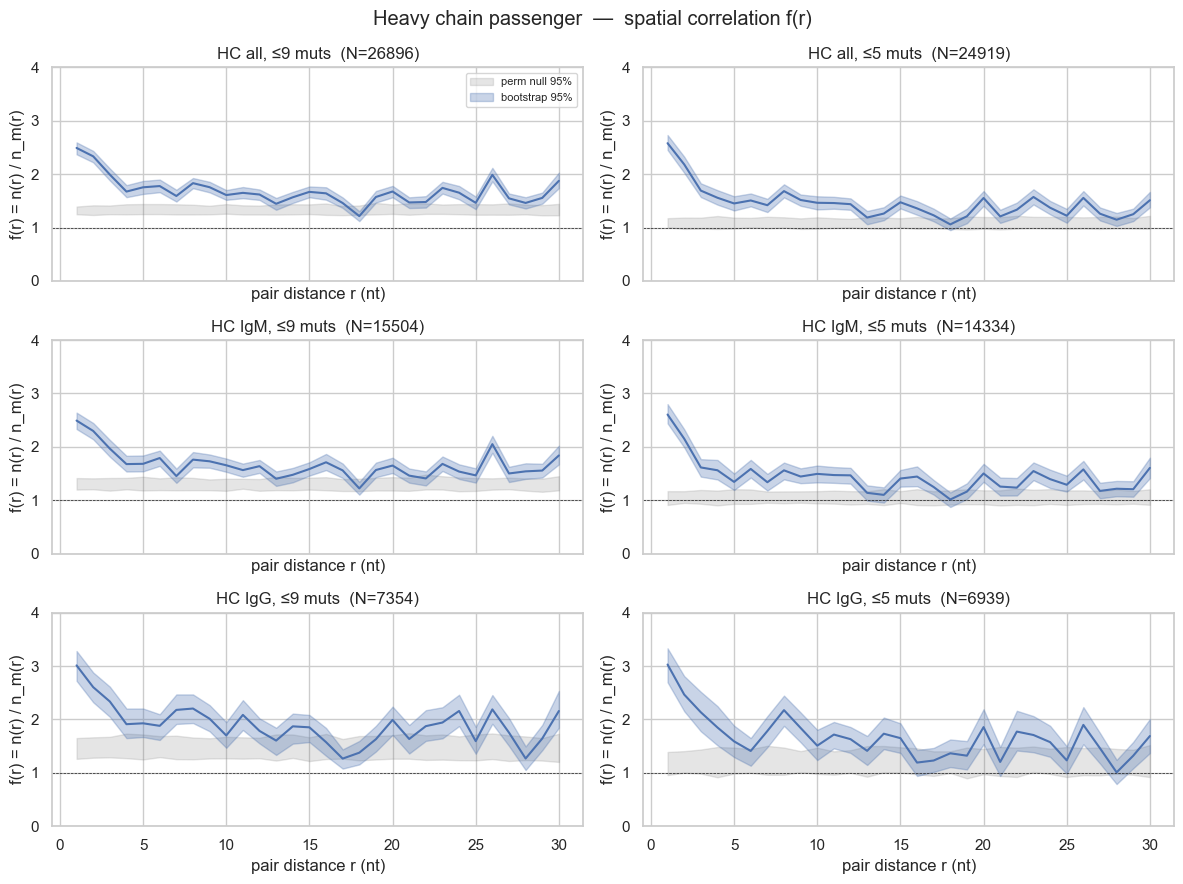

In [15]:
fig, axes = plt.subplots(
    nrows=(len(hc_stats) + 1) // 2, ncols=2, figsize=(12, 3 * ((len(hc_stats) + 1) // 2)),
    sharex=True,
)
axes = np.asarray(axes).flatten()
for ax, (label, stats) in zip(axes, hc_stats.items()):
    plot_fr(ax, stats, label)
    ax.set_ylim(0, max(4, np.nanmax(stats["f_hi"][1 : R_MAX + 1]) * 1.1))
for ax in axes[len(hc_stats) :]:
    ax.axis("off")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Heavy chain passenger  —  spatial correlation f(r)")
fig.tight_layout()

### LC: pooled IgM (8A / 9A / 11A)

In [16]:
def lc_panels():
    L = len(CHIGY_LC.chigy_stop_trimmed)
    panels = {
        "LC pooled, ≤9 muts": lc_bel,
        "LC pooled, ≤5 muts": lc_bel[lc_bel["mutation_count"] <= LOW_LOAD_CAP],
    }
    stats = {k: compute_fr_stats(v, L) for k, v in panels.items()}
    return stats


print("Computing LC panels ...")
lc_stats = lc_panels()

Computing LC panels ...


/var/folders/16/pkph6n2962g3lf2wpwwt0wwr0000gn/T/ipykernel_25407/2834763921.py:105: RuntimeWarning: Mean of empty slice
  f_mean = np.nanmean(f_samples, axis=0)


/var/folders/16/pkph6n2962g3lf2wpwwt0wwr0000gn/T/ipykernel_25407/2834763921.py:180: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(f_samples, axis=0)


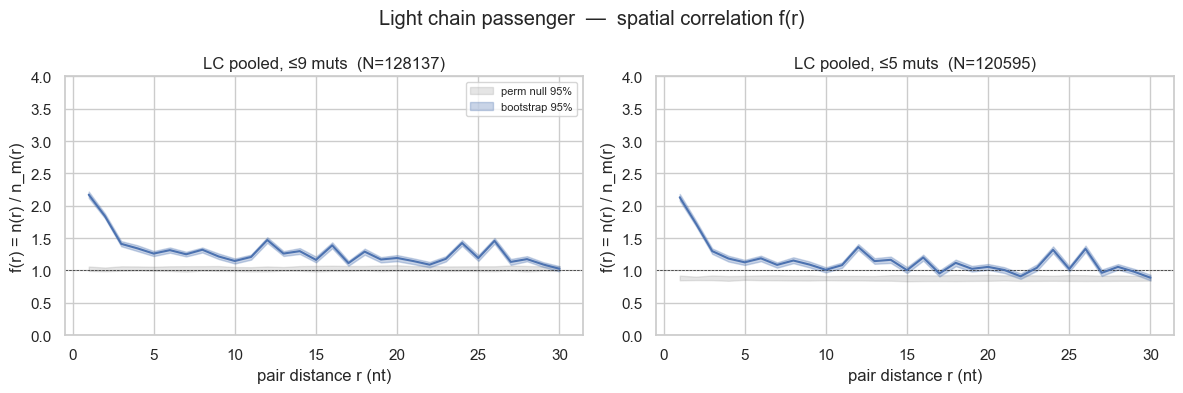

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)
for ax, (label, stats) in zip(axes, lc_stats.items()):
    plot_fr(ax, stats, label)
    ax.set_ylim(0, max(4, np.nanmax(stats["f_hi"][1 : R_MAX + 1]) * 1.1))
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Light chain passenger  —  spatial correlation f(r)")
fig.tight_layout()

## A note on $r = 1$

Biological multinucleotide mutations from error-prone repair and
polymerase $\eta/\zeta$ activity should peak at the shortest
distances, including $r = 1$. Unfortunately, several technical
artifacts also concentrate specifically at $r = 1$, so the $r = 1$
bin mixes biology with noise:

1. **Correlated Illumina base-calling errors** at adjacent cycles
   (after homopolymer runs, GGC contexts, low-quality tails). The
   UMI-collapsed `atleast-2` consensus in the gcreplay pipeline
   damps this substantially but does not eliminate it.
2. **Ambiguous gap placement** during pairwise alignment. A real
   1-nt indel near a real substitution can be re-scored into an
   adjacent-substitution configuration with near-identical
   alignment score. `summarize_alignment` excludes read gaps from
   mutation counts, so gap-as-mutation is prevented, but gap
   reshuffling that converts one real mismatch into two adjacent
   mismatches is not.
3. **PCR misincorporation with correlated extension**: a polymerase
   that misincorporates once can, in certain sequence contexts,
   misincorporate again at the next position before dissociating.
   The footprint is specifically at $r = 1$.
4. **Codon/frame confounds**: $r = 1$ is the only distance at
   which the pair is guaranteed to sit in the same codon, so any
   codon-context-dependent sequencing or alignment bias
   concentrates there rather than distributing across $r$.

All four mechanisms decay sharply with $r$ and are typically
order-of-magnitude weaker by $r = 2$. We **do** plot and report
$r = 1$ below, but also separately report the success criterion
over $r \in [2, 5]$ (where biology dominates) and over
$r \in [1, 5]$ (where biology is largest but artifacts are
present). An obvious follow-up is comparing the $r = 1$ point to
the extrapolated short-range trend to see whether it sits on the
biological curve or overshoots it.

## Success-criteria readout

Declare **positive** if, in at least one chain, the bootstrap lower
bound of $f(r)$ exceeds 1.5 at some $r \in [2, 5]$. We also report
the $r \in [1, 5]$ window for comparison (artifact-susceptible).

In [18]:
def summarize_panel(label: str, stats: dict) -> dict:
    f_point = stats["f_point"]
    f_lo = stats["f_lo"]
    r_2_5 = np.arange(2, 6)
    r_1_5 = np.arange(1, 6)
    return {
        "panel": label,
        "n_reads": stats["n_reads"],
        "f_r1": float(f_point[1]),
        "f_lo_r1": float(f_lo[1]),
        "f_mean_r2_5": float(np.nanmean(f_point[r_2_5])),
        "f_lo_max_r2_5": float(np.nanmax(f_lo[r_2_5])),
        "positive_at_r2_5": bool(np.nanmax(f_lo[r_2_5]) > 1.5),
        "f_mean_r1_5": float(np.nanmean(f_point[r_1_5])),
        "f_lo_max_r1_5": float(np.nanmax(f_lo[r_1_5])),
    }


summary_rows = []
for label, stats in {**hc_stats, **lc_stats}.items():
    summary_rows.append(summarize_panel(label, stats))
summary_df = pd.DataFrame(summary_rows)
summary_df

,panel,n_reads,f_r1,f_lo_r1,f_mean_r2_5,f_lo_max_r2_5,positive_at_r2_5,f_mean_r1_5,f_lo_max_r1_5
0,"HC all, ≤9 muts",26896,2.491862,2.372714,1.939046,2.222606,True,2.049609,2.372714
1,"HC all, ≤5 muts",24919,2.580691,2.454215,1.721705,2.027661,True,1.893503,2.454215
2,"HC IgM, ≤9 muts",15504,2.491031,2.333102,1.904914,2.140853,True,2.022137,2.333102
3,"HC IgM, ≤5 muts",14334,2.604144,2.439411,1.666889,1.990369,True,1.854340,2.439411
4,"HC IgG, ≤9 muts",7354,3.011356,2.722767,2.194063,2.320998,True,2.357522,2.722767
5,"HC IgG, ≤5 muts",6939,3.027547,2.695805,2.008801,2.154157,True,2.212550,2.695805
6,"LC pooled, ≤9 muts",128137,2.171741,2.122090,1.463724,1.806523,True,1.605328,2.122090
7,"LC pooled, ≤5 muts",120595,2.131186,2.077088,1.333975,1.686220,True,1.493417,2.077088


In [19]:
any_positive = summary_df["positive_at_r2_5"].any()
print("=" * 60)
if any_positive:
    print("RESULT: POSITIVE — at least one panel shows f(r) bootstrap")
    print("lower bound > 1.5 at some r ∈ [2, 5].")
else:
    print("RESULT: NEGATIVE or AMBIGUOUS — no panel crosses the")
    print("positive threshold. Inspect plots and reconsider caps /")
    print("stratification.")
print("=" * 60)

RESULT: POSITIVE — at least one panel shows f(r) bootstrap
lower bound > 1.5 at some r ∈ [2, 5].


### How does the $r = 1$ point relate to the short-range trend?

If the $r = 1$ bin is dominated by biology, it should sit on or
above the extrapolation of $f(r)$ for $r \in [2, 5]$. If it is
dominated by artifacts, it should overshoot the extrapolation.
Here we compare $f(1)$ to a simple linear extrapolation of
$f(r)$ from $r = 2, 3, 4, 5$ back to $r = 1$.

In [20]:
def r1_vs_extrapolation(stats: dict) -> dict:
    f_point = stats["f_point"]
    x = np.array([2, 3, 4, 5], dtype=float)
    y = f_point[x.astype(int)]
    # linear fit y = a + b*x
    A = np.vstack([np.ones_like(x), x]).T
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b = coef
    pred_r1 = a + b * 1.0
    return {
        "f_r1_obs": float(f_point[1]),
        "f_r1_linear_extrap_from_r2_5": float(pred_r1),
        "excess_r1": float(f_point[1] - pred_r1),
    }


r1_rows = []
for label, stats in {**hc_stats, **lc_stats}.items():
    row = {"panel": label, **r1_vs_extrapolation(stats)}
    r1_rows.append(row)
r1_df = pd.DataFrame(r1_rows)
r1_df

,panel,f_r1_obs,f_r1_linear_extrap_from_r2_5,excess_r1
0,"HC all, ≤9 muts",2.491862,2.453620,0.038242
1,"HC all, ≤5 muts",2.580691,2.304019,0.276672
2,"HC IgM, ≤9 muts",2.491031,2.439172,0.051859
3,"HC IgM, ≤5 muts",2.604144,2.287091,0.317054
4,"HC IgG, ≤9 muts",3.011356,2.808012,0.203343
5,"HC IgG, ≤5 muts",3.027547,2.737712,0.289836
6,"LC pooled, ≤9 muts",2.171741,1.914943,0.256799
7,"LC pooled, ≤5 muts",2.131186,1.811858,0.319328


## Multi-nucleotide codon mutations relative to single-nucleotide

The spatial correlation function above shows that mutations
co-localize at short distances. A related and more biologically
actionable question — directly relevant to the main gcreplay
manuscript's finding that multi-nucleotide codon changes are hard
to reach even for beneficial amino acids — is:

> Out of all codons that carry at least one mutation in a given
> read, what fraction carry two or three mutations, and how does
> that compare to the independent-sites expectation?

The ratio observed / expected for $k = 2, 3$ mutations per codon
is exactly what the DASM "multihit correction" of
[Matsen et al. 2025](https://doi.org/10.1101/2025.10.21.683652)
fits as three scalar rate multipliers $M_1, M_2, M_3$ on
out-of-frame data. Here we estimate the same multipliers directly
from the passenger allele, with a fixed known template and no
selection.

Frame: both `CHIGY_HC_STOP_TRIMMED` and `CHIGY_LC_STOP_TRIMMED`
translate cleanly in frame 0 as Ig V-region ORFs (verified above),
so codon $c$ spans positions $3c, 3c+1, 3c+2$. The trailing
fractional codon (1 nt for HC, 1 nt for LC) is dropped.

In [21]:
def codon_k_histogram_observed(
    positions_list: list[np.ndarray], L: int
) -> np.ndarray:
    """Return an array ``obs`` of length 4 where ``obs[k]`` is the
    total number of codons that carry exactly ``k`` nucleotide
    mutations across all reads, for ``k ∈ {0, 1, 2, 3}``. The
    ``obs[0]`` entry is the number of un-mutated codons across reads
    (computed by subtraction for efficiency).
    """
    num_codons = L // 3
    max_pos = 3 * num_codons  # exclusive upper bound for full codons
    obs = np.zeros(4, dtype=np.int64)
    total_codon_slots = num_codons * len(positions_list)
    for positions in positions_list:
        if len(positions) == 0:
            continue
        arr = np.asarray(positions, dtype=np.int64)
        arr = arr[arr < max_pos]
        if arr.size == 0:
            continue
        codon_idx = arr // 3
        u, c = np.unique(codon_idx, return_counts=True)
        # c holds per-codon hit counts; cap at 3
        for count in c:
            if 1 <= count <= 3:
                obs[count] += 1
    obs[0] = total_codon_slots - obs[1] - obs[2] - obs[3]
    return obs


def codon_k_histogram_expected(p: np.ndarray, n_reads: int) -> np.ndarray:
    """Expected number of codons with k=0,1,2,3 nucleotide mutations
    under per-site Bernoulli(p_i), summed over codons and multiplied
    by n_reads.
    """
    L = len(p)
    num_codons = L // 3
    exp = np.zeros(4, dtype=np.float64)
    for c in range(num_codons):
        p1, p2, p3 = p[3 * c], p[3 * c + 1], p[3 * c + 2]
        q1, q2, q3 = 1 - p1, 1 - p2, 1 - p3
        P0 = q1 * q2 * q3
        P1 = p1 * q2 * q3 + q1 * p2 * q3 + q1 * q2 * p3
        P2 = p1 * p2 * q3 + p1 * q2 * p3 + q1 * p2 * p3
        P3 = p1 * p2 * p3
        exp += np.array([P0, P1, P2, P3])
    return n_reads * exp


def codon_k_report(bel_df: pd.DataFrame, L: int, label: str) -> dict:
    positions_list = [np.asarray(x, dtype=np.int64) for x in bel_df["mutation_positions"]]
    p = empirical_p(bel_df, L)
    n_reads = len(bel_df)
    obs = codon_k_histogram_observed(positions_list, L)
    exp = codon_k_histogram_expected(p, n_reads)
    # Fractions of mutated codons
    mutated_obs = obs[1] + obs[2] + obs[3]
    mutated_exp = exp[1] + exp[2] + exp[3]
    frac_obs = np.array([obs[k] / mutated_obs if mutated_obs > 0 else np.nan for k in range(1, 4)])
    frac_exp = np.array([exp[k] / mutated_exp if mutated_exp > 0 else np.nan for k in range(1, 4)])
    # Multihit multipliers M_k = observed / expected
    with np.errstate(divide="ignore", invalid="ignore"):
        M = np.array([obs[k] / exp[k] if exp[k] > 0 else np.nan for k in range(1, 4)])
    return {
        "panel": label,
        "n_reads": n_reads,
        "n_codons_total": int(obs.sum()),
        "obs_k1": int(obs[1]),
        "obs_k2": int(obs[2]),
        "obs_k3": int(obs[3]),
        "exp_k1": float(exp[1]),
        "exp_k2": float(exp[2]),
        "exp_k3": float(exp[3]),
        "frac_mut_k1_obs": float(frac_obs[0]),
        "frac_mut_k2_obs": float(frac_obs[1]),
        "frac_mut_k3_obs": float(frac_obs[2]),
        "frac_mut_k1_exp": float(frac_exp[0]),
        "frac_mut_k2_exp": float(frac_exp[1]),
        "frac_mut_k3_exp": float(frac_exp[2]),
        "M1": float(M[0]),
        "M2": float(M[1]),
        "M3": float(M[2]),
    }


codon_rows = []
L_hc = len(CHIGY_HC.chigy_stop_trimmed)
L_lc = len(CHIGY_LC.chigy_stop_trimmed)
for label, df in [
    ("HC all", hc_bel),
    ("HC IgM", hc_bel[hc_bel["isotype"] == "IgM"]),
    ("HC IgG", hc_bel[hc_bel["isotype"] == "IgG"]),
    ("HC all, ≤5 muts", hc_bel[hc_bel["mutation_count"] <= LOW_LOAD_CAP]),
]:
    if len(df) > 0:
        codon_rows.append(codon_k_report(df, L_hc, label))
for label, df in [
    ("LC pooled", lc_bel),
    ("LC pooled, ≤5 muts", lc_bel[lc_bel["mutation_count"] <= LOW_LOAD_CAP]),
]:
    if len(df) > 0:
        codon_rows.append(codon_k_report(df, L_lc, label))
codon_df = pd.DataFrame(codon_rows)

# Pretty-printed view of the two most interesting slices
display_cols = [
    "panel", "n_reads", "obs_k1", "obs_k2", "obs_k3",
    "frac_mut_k2_obs", "frac_mut_k2_exp",
    "frac_mut_k3_obs", "frac_mut_k3_exp",
    "M2", "M3",
]
codon_df[display_cols]

,panel,n_reads,obs_k1,obs_k2,obs_k3,frac_mut_k2_obs,frac_mut_k2_exp,frac_mut_k3_obs,frac_mut_k3_exp,M2,M3
0,HC all,26896,55230,1655,66,0.029060,0.012630,0.001159,0.000082,2.259394,13.867691
1,HC IgM,15504,32901,991,40,0.029205,0.012746,0.001179,0.000085,2.249904,13.550633
2,HC IgG,7354,12685,397,17,0.030308,0.011202,0.001298,0.000062,2.649130,20.351393
3,"HC all, ≤5 muts",24919,42760,1078,42,0.024567,0.010536,0.000957,0.000057,2.295865,16.433443
4,LC pooled,128137,300095,8092,122,0.026246,0.011289,0.000396,0.000052,2.289533,7.542810
5,"LC pooled, ≤5 muts",120595,254443,6072,69,0.023302,0.010192,0.000265,0.000042,2.256084,6.207602


### Interpretation of the codon multi-hit table

- **`frac_mut_k2_obs` and `frac_mut_k3_obs`** are the fractions of
  mutated codons (across all reads) that have exactly 2 or 3
  nucleotide substitutions. This is the direct answer to the
  "absolute rate of multi-nt vs single-nt codon mutations" question,
  measured on a selection-free substrate.
- **`frac_mut_k2_exp` and `frac_mut_k3_exp`** are the same fractions
  predicted by the independent-sites null with per-site marginals
  `p_i`. These are what a model like thrifty would predict without a
  multihit correction.
- **`M2 = obs_k2 / exp_k2`** and **`M3 = obs_k3 / exp_k3`** are
  empirical multihit-correction multipliers on a per-codon basis.
  These are directly comparable to DASM's three scalar multipliers
  (1/2/3 mutations per codon) fit on separate out-of-frame data.
- Numbers significantly above 1 for M2 and especially M3 mean the
  SHM process concentrates mutations within single codons at a rate
  well above what per-site independence predicts — i.e. the
  co-localization signal detected by $f(r)$ translates into an
  excess of multi-nt codon changes. This is the mechanism by which
  SHM can reach amino acids requiring multi-nt codon paths at all;
  under strict independence, multi-nt codon changes would be so
  rare that the "hard to reach even if beneficial" observation in
  the gcreplay manuscript would be even more extreme.

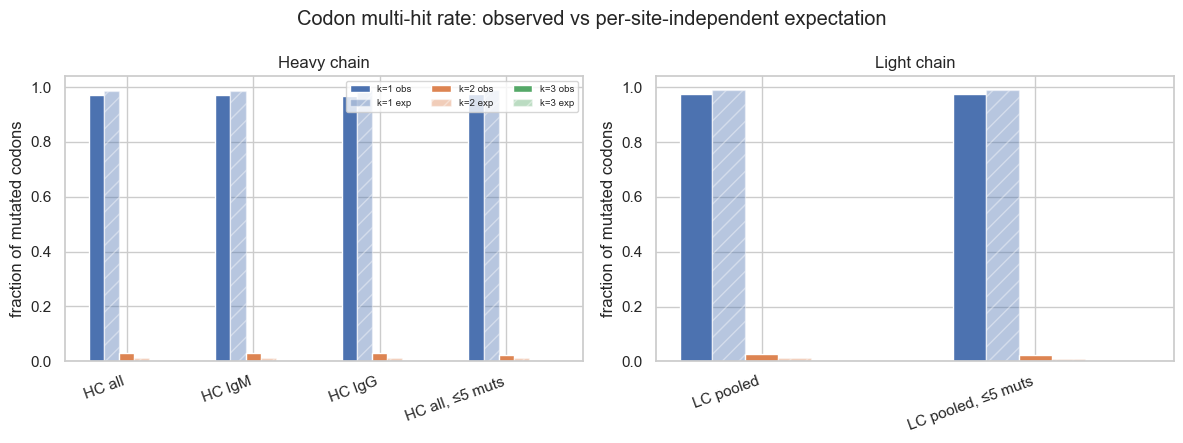

In [22]:
# Bar plot: observed vs expected fraction of mutated codons for k=1,2,3
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))
for ax, (chain, mask) in zip(
    axes,
    [
        ("Heavy chain", codon_df["panel"].str.startswith("HC")),
        ("Light chain", codon_df["panel"].str.startswith("LC")),
    ],
):
    sub = codon_df[mask]
    x = np.arange(len(sub))
    width = 0.12
    for i, k in enumerate([1, 2, 3]):
        ax.bar(x + (i - 1) * 2 * width, sub[f"frac_mut_k{k}_obs"], width,
               label=f"k={k} obs", color=f"C{i}")
        ax.bar(x + (i - 1) * 2 * width + width, sub[f"frac_mut_k{k}_exp"], width,
               label=f"k={k} exp", color=f"C{i}", alpha=0.4, hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["panel"], rotation=20, ha="right")
    ax.set_ylabel("fraction of mutated codons")
    ax.set_title(chain)
axes[0].legend(fontsize=7, ncol=3, loc="upper right")
fig.suptitle("Codon multi-hit rate: observed vs per-site-independent expectation")
fig.tight_layout()

### Correctness check for the codon analysis

For the synthetic per-site Bernoulli data we already use in the
known-answer test, the observed codon-k distribution should exactly
match the expected one (up to Monte-Carlo noise), because the
generative and null models are the same.

In [23]:
def codon_k_self_consistency(bel_df: pd.DataFrame, L: int, label: str, n_synth: int = 200000) -> None:
    """On Bernoulli(p_i) synthetic data, observed and expected codon-k
    histograms should agree up to Poisson noise. We assert that the
    deviation is within 4 Poisson standard deviations of the expected
    count, which is a weak correctness test (catches gross bugs in the
    observed histogram or the expected formula) but is not a
    statistical validation."""
    p = empirical_p(bel_df, L)
    synth = generate_bernoulli_reads(n_synth, p, RNG)
    obs = codon_k_histogram_observed(synth, L)
    exp = codon_k_histogram_expected(p, n_synth)
    for k in [1, 2, 3]:
        sigma = max(1.0, float(np.sqrt(exp[k]))) if exp[k] > 0 else 1.0
        rel_err = (obs[k] - exp[k]) / exp[k] if exp[k] > 0 else float("nan")
        z = (obs[k] - exp[k]) / sigma
        print(
            f"  {label} k={k}: obs={obs[k]}, exp={exp[k]:.1f}, "
            f"rel_err={rel_err:+.3f}, z={z:+.2f}"
        )
        assert abs(z) < 4.0, (
            f"{label} codon k={k} |z|={abs(z):.2f} > 4 (obs={obs[k]}, exp={exp[k]:.1f})"
        )


print("Codon k-histogram self-consistency on Bernoulli synthetic data:")
codon_k_self_consistency(hc_bel, L_hc, "HC")
codon_k_self_consistency(lc_bel, L_lc, "LC")

Codon k-histogram self-consistency on Bernoulli synthetic data:


  HC k=1: obs=425957, exp=425778.8, rel_err=+0.000, z=+0.27
  HC k=2: obs=5507, exp=5446.9, rel_err=+0.011, z=+0.81
  HC k=3: obs=40, exp=35.4, rel_err=+0.130, z=+0.77


  LC k=1: obs=481802, exp=483120.1, rel_err=-0.003, z=-1.90
  LC k=2: obs=5520, exp=5516.5, rel_err=+0.001, z=+0.05
  LC k=3: obs=35, exp=25.2, rel_err=+0.386, z=+1.94
